# Experiment 1: Linear and Logistic Regression\n\n**Objective:**\n- Part A: Implement Simple Linear Regression on `insurance.csv` to predict medical expenses.\n- Part B: Implement Logistic Regression on `bank.csv` to predict term deposit subscription.

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

## Part A: Simple Linear Regression\n**Dataset:** `insurance.csv` | **Target:** `expenses` | **Feature:** `bmi`

In [2]:
# Load insurance dataset
insurance = pd.read_csv('insurance.csv')
print("Shape:", insurance.shape)
print("\nFirst 5 rows:")
insurance.head()

Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


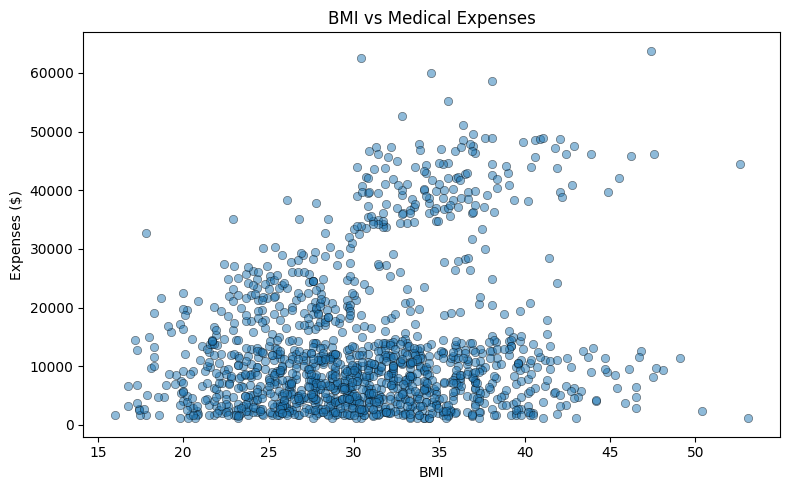

In [3]:
# Scatter plot: BMI vs Expenses
plt.figure(figsize=(8, 5))
plt.scatter(insurance['bmi'], insurance['expenses'], alpha=0.5, edgecolors='k', linewidths=0.5)
plt.xlabel('BMI')
plt.ylabel('Expenses ($)')
plt.title('BMI vs Medical Expenses')
plt.tight_layout()
plt.show()

Coefficient (slope): 392.8745
Intercept: 1338.9995

Mean Squared Error : 149066159.51
R2 Score           : 0.0398


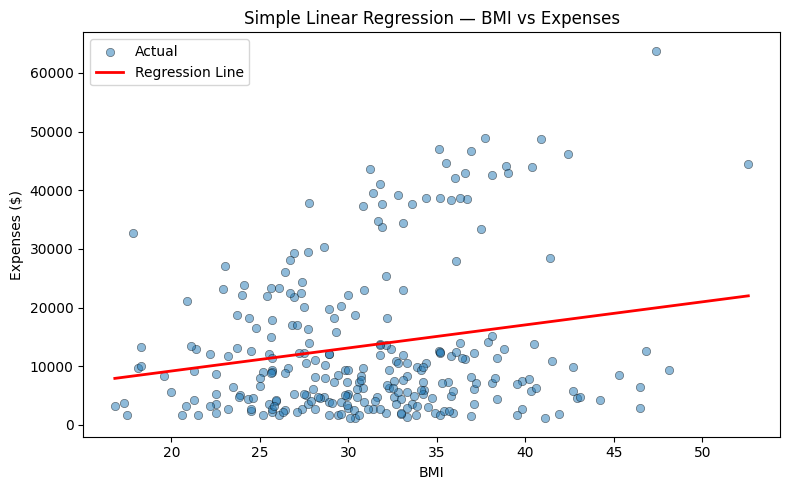

In [4]:
# Simple Linear Regression: BMI -> Expenses
X_lin = insurance[['bmi']]
y_lin = insurance['expenses']

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train_lin, y_train_lin)
y_pred_lin = lr_model.predict(X_test_lin)

print(f"Coefficient (slope): {lr_model.coef_[0]:.4f}")
print(f"Intercept: {lr_model.intercept_:.4f}")
print(f"\nMean Squared Error : {mean_squared_error(y_test_lin, y_pred_lin):.2f}")
print(f"R2 Score           : {r2_score(y_test_lin, y_pred_lin):.4f}")

# Plot regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_test_lin, y_test_lin, alpha=0.5, label='Actual', edgecolors='k', linewidths=0.5)
plt.plot(X_test_lin.sort_values('bmi'), lr_model.predict(X_test_lin.sort_values('bmi')),
         color='red', linewidth=2, label='Regression Line')
plt.xlabel('BMI')
plt.ylabel('Expenses ($)')
plt.title('Simple Linear Regression — BMI vs Expenses')
plt.legend()
plt.tight_layout()
plt.show()

## Part B: Logistic Regression\n**Dataset:** `bank.csv` | **Target:** `deposit` (yes/no)

In [5]:
# Load bank dataset
bank = pd.read_csv('bank.csv')
print("Shape:", bank.shape)
print("\nMissing values:\n", bank.isnull().sum().sum())
print("\nTarget distribution:")
print(bank['deposit'].value_counts())
bank.head()

Shape: (11162, 17)

Missing values:
 0

Target distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
# Preprocessing
# Encode target: yes -> 1, no -> 0
bank['deposit'] = bank['deposit'].map({'yes': 1, 'no': 0})

# One-hot encode categorical features
bank_encoded = pd.get_dummies(bank, drop_first=True)

# Features and target
X_log = bank_encoded.drop('deposit', axis=1)
y_log = bank_encoded['deposit']

print("Encoded feature shape:", X_log.shape)
X_log.head()

Encoded feature shape: (11162, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [7]:
# Train-Test Split
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)
y_pred_log = log_model.predict(X_test_log)

print(f"Accuracy: {accuracy_score(y_test_log, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log, target_names=['No', 'Yes']))

Accuracy: 0.8056

Classification Report:
              precision    recall  f1-score   support

          No       0.81      0.83      0.82      1166
         Yes       0.81      0.78      0.79      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.80      0.80      2233
weighted avg       0.81      0.81      0.81      2233



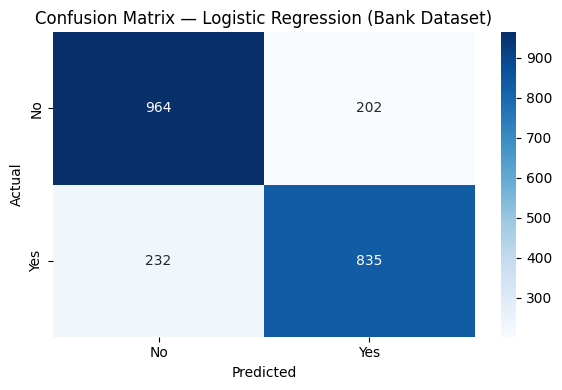

In [8]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test_log, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression (Bank Dataset)')
plt.tight_layout()
plt.show()